In [64]:
#Carregar as bibliotecas

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import os
import cv2
from tqdm import tqdm
import random
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.math import confusion_matrix
import seaborn as sns
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
tf.keras.utils.set_random_seed(3)
tf.config.experimental.enable_op_determinism()

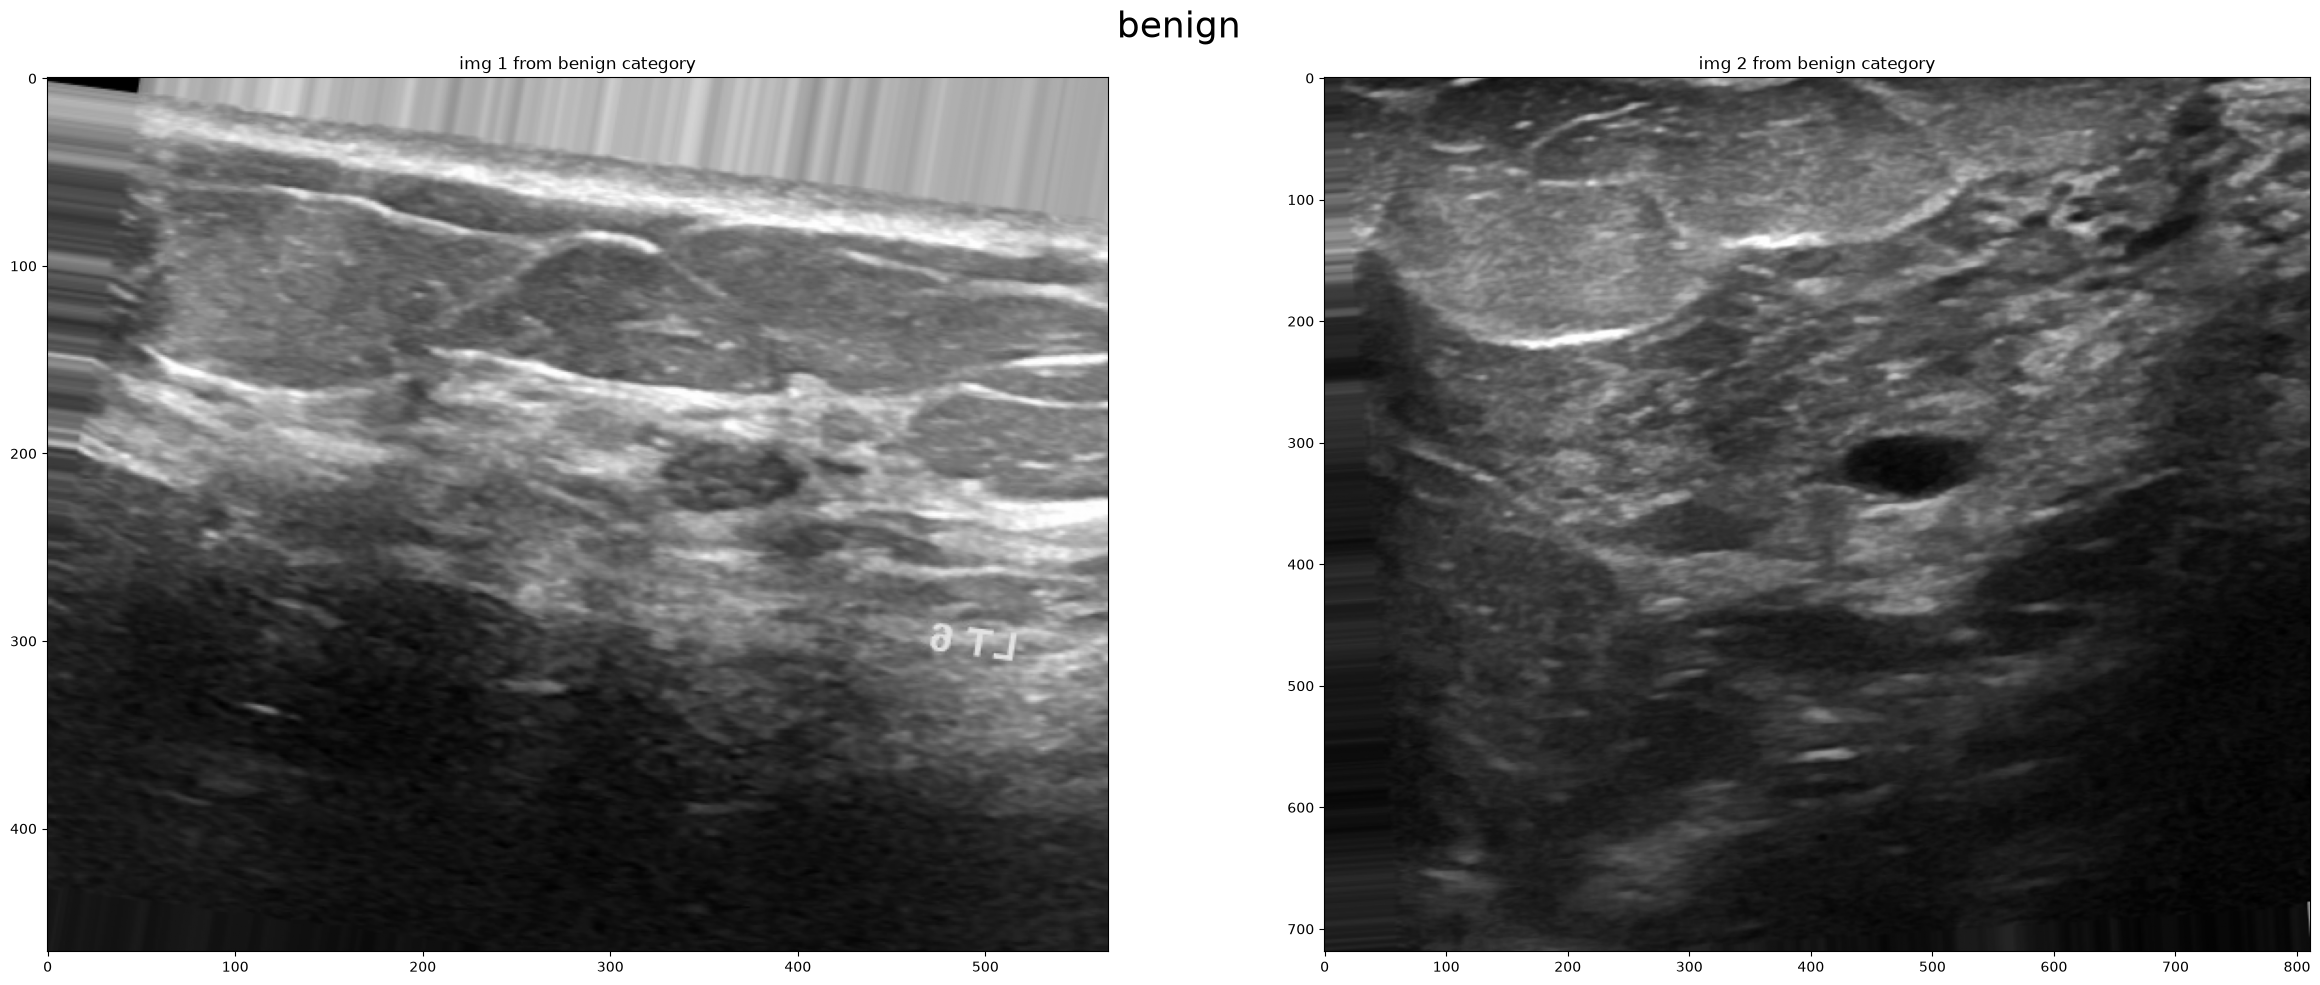

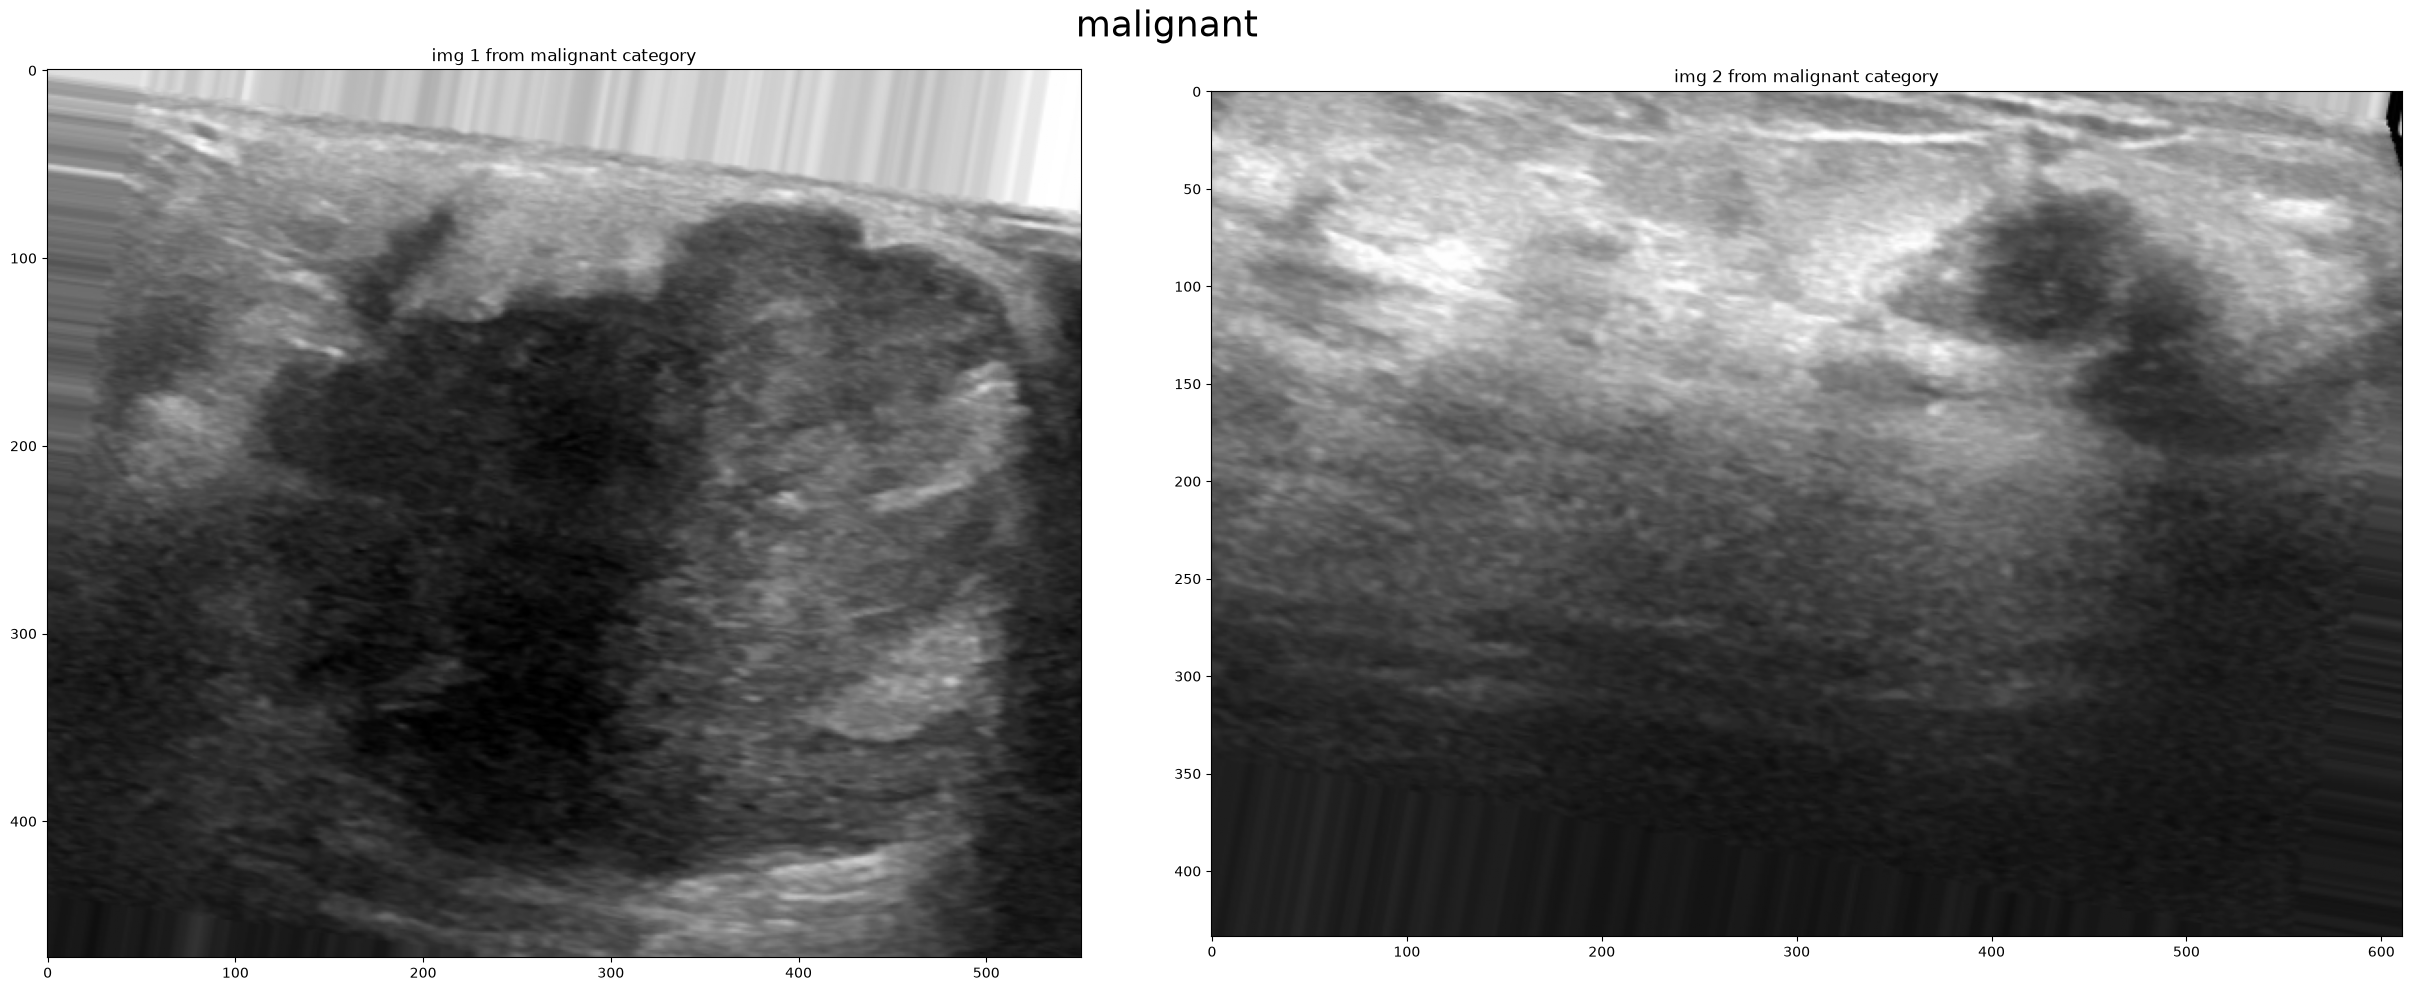

In [65]:
#Dados sobre conjunto de imagens de ultrassom de mama que contém 2 Classes [benigno, maligno] Exibindo 2 imagens de cada classe

import os
import cv2
import matplotlib.pyplot as plt

# Novo caminho da base de dados
folder_name = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/BUSI_CLEAN/train_augmented'
files_names = ['benign', 'malignant']  # Apenas as duas classes desejadas

for file in files_names:
    path = os.path.join(folder_name, file)
    x = 0
    fig, axes = plt.subplots(1, 2, figsize=(25, 10))  
    
    for img in os.listdir(path):
        if not img.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue  # Ignora arquivos que não são imagens

        img_path = os.path.join(path, img)
        if not os.path.isfile(img_path):
            continue  # Garante que é um arquivo

        img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img_array is None:
            continue  # Ignora arquivos corrompidos ou inválidos

        axes[x].imshow(img_array, cmap='gray')
        axes[x].set_title(f"img {x+1} from {file} category")
        x += 1
        if x == 2: 
            break

    plt.suptitle(file, fontsize=26)
    plt.tight_layout()
    plt.show()

In [66]:
# Carregando dados

import os
import cv2
from tqdm import tqdm

# Caminho para a pasta contendo as imagens de treino
folder_name = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/BUSI_CLEAN/train_augmented'

# Classes que queremos carregar
files_names = ['benign', 'malignant']

# Tamanho das imagens
img_sz = 224

# Lista para armazenar os dados de treino
training_data = []

def create_training_data():
    for file in files_names:
        path = os.path.join(folder_name, file)
        class_num = files_names.index(file)  # 0 para benign, 1 para malignant
        print(file, class_num)

        for img in tqdm(os.listdir(path)):
            img_path = os.path.join(path, img)

            # Filtros para evitar imagens indesejadas
            if not img.lower().endswith('.png'):
                continue
            if not os.path.isfile(img_path):
                continue

            img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img_array is None:
                continue  # evita erro se a imagem estiver corrompida

            new_array = cv2.resize(img_array, (img_sz, img_sz))
            training_data.append([new_array, class_num])

# Executar a função
create_training_data()


benign 0


100%|█████████████████████████████████████| 1302/1302 [00:03<00:00, 382.83it/s]


malignant 1


100%|███████████████████████████████████████| 744/744 [00:01<00:00, 410.75it/s]


In [67]:
# Os dados têm imagens benignas e malignas. Embaralhando e exibindo as primeiras 20 classes

import random

# Embaralha os dados de treino
random.shuffle(training_data)

# Exibe as primeiras 30 amostras com suas classes
for i in range(30):
    print(f"Sample {i+1}:")
    print("Class number:", training_data[i][1], "\n")


Sample 1:
Class number: 0 

Sample 2:
Class number: 1 

Sample 3:
Class number: 1 

Sample 4:
Class number: 1 

Sample 5:
Class number: 0 

Sample 6:
Class number: 0 

Sample 7:
Class number: 1 

Sample 8:
Class number: 0 

Sample 9:
Class number: 1 

Sample 10:
Class number: 1 

Sample 11:
Class number: 0 

Sample 12:
Class number: 1 

Sample 13:
Class number: 0 

Sample 14:
Class number: 0 

Sample 15:
Class number: 0 

Sample 16:
Class number: 1 

Sample 17:
Class number: 0 

Sample 18:
Class number: 0 

Sample 19:
Class number: 1 

Sample 20:
Class number: 1 

Sample 21:
Class number: 0 

Sample 22:
Class number: 0 

Sample 23:
Class number: 0 

Sample 24:
Class number: 0 

Sample 25:
Class number: 1 

Sample 26:
Class number: 0 

Sample 27:
Class number: 0 

Sample 28:
Class number: 1 

Sample 29:
Class number: 0 

Sample 30:
Class number: 1 



In [68]:
import numpy as np

X = []
y = []

# Percorre as amostras de treinamento
for feature, label in training_data:
    X.append(feature)
    y.append(label)

# Converte as listas em arrays numpy
X = np.array(X)
y = np.array(y)

# Adiciona a dimensão para o canal (escala de cinza)
X = np.expand_dims(X, axis=-1)  # Adiciona a dimensão do canal de cor (1 para grayscale)

# Verificando a forma de X e y
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (2046, 224, 224, 1)
y shape: (2046,)


In [69]:
from sklearn.model_selection import train_test_split

# Divisão dos dados em treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificar as formas dos conjuntos de dados
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(1636, 224, 224, 1)
(1636,)
(410, 224, 224, 1)
(410,)


In [70]:
# Valores únicos em y (Classes)

print(np.unique(y_train))

print(np.unique(y_test))

[0 1]
[0 1]


In [71]:
# Normalização para 0-1
X_train = X_train/255
X_test = X_test/255

In [72]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Modelo CNN sem mecanismo de atenção
img_sz = 224

inputs = layers.Input(shape=(img_sz, img_sz, 1))

x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

x = layers.Conv2D(128, (3, 3), dilation_rate=2, padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

x = layers.Conv2D(256, (3, 3), dilation_rate=2, padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(64, activation='relu')(x)

outputs = layers.Dense(2, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431,042 (1.64 MB)

 Trainable params: 430,082 (1.64 MB)

 Non-trainable params: 960 (3.75 KB)

In [73]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss',  # ou 'val_accuracy'
                               patience=10,          # número de épocas sem melhora antes de parar
                               restore_best_weights=True)  # restaura os melhores pesos

history = model.fit(X_train, y_train,
                    epochs=50,
                    validation_split=0.2,
                    batch_size=8,
                    callbacks=[early_stopping])

Epoch 1/50


E0000 00:00:1786152638.625157   50042 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7018 - loss: 0.5913 - val_accuracy: 0.3262 - val_loss: 1.3460
Epoch 2/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7355 - loss: 0.5527 - val_accuracy: 0.3262 - val_loss: 2.1258
Epoch 3/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7653 - loss: 0.5198 - val_accuracy: 0.4238 - val_loss: 1.5829
Epoch 4/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7829 - loss: 0.4818 - val_accuracy: 0.5610 - val_loss: 0.9491
Epoch 5/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7943 - loss: 0.4646 - val_accuracy: 0.8018 - val_loss: 0.4485
Epoch 6/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7936 - loss: 0.4517 - val_accuracy: 0.7774 - val_loss: 0.4612
Epoch 7/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8257 - loss: 0.4143 - val_accuracy: 0.7591 - val_loss: 0.5443
Epoch 8/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8402 - loss: 0.3859 - val_accuracy: 0.750

In [74]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Accuarcy of the model is : {accuracy*100:.2f} %")

 1/13 ━━━━━━━━━━━━━━━━━━━━ 2s 221ms/step - accuracy: 0.9062 - loss: 0.1926

E0000 00:00:1786152711.283059   50042 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8976 - loss: 0.2342
Accuarcy of the model is : 89.76 %


In [75]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Fazer a predição com o modelo
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Gerar a matriz de confusão
conf_mat = confusion_matrix(y_test, y_pred_classes)



13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


In [76]:
y_pred = [np.argmax(i) for i in y_pred]
print(y_pred)

[np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0)

In [77]:
# Supondo que você tenha as classes "Benign" e "Malignant"
comparison_df = pd.DataFrame({ 'Actual': y_test,'Predicted': y_pred})

print(comparison_df[:20])

    Actual  Predicted
0        0          0
1        1          1
2        0          0
3        1          1
4        1          1
5        0          0
6        0          0
7        0          0
8        0          0
9        0          0
10       1          0
11       1          1
12       1          1
13       0          0
14       1          1
15       0          0
16       1          1
17       0          0
18       0          0
19       0          0


In [78]:
from sklearn.metrics import classification_report
import numpy as np

# Obter as predições do modelo no conjunto de teste completo
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Relatório de classificação
print(classification_report(y_test, y_pred, target_names=['benign', 'malignant']))


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
              precision    recall  f1-score   support

      benign       0.93      0.91      0.92       266
   malignant       0.84      0.88      0.86       144

    accuracy                           0.90       410
   macro avg       0.88      0.89      0.89       410
weighted avg       0.90      0.90      0.90       410



E0000 00:00:1786152770.804067   50042 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


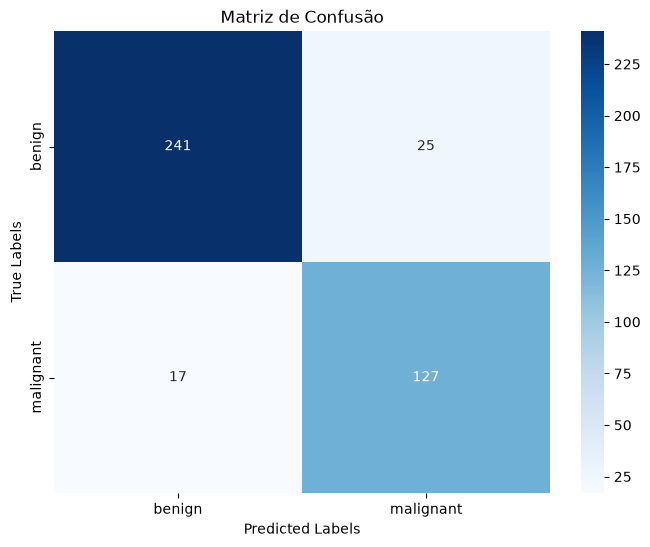

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mostrar a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['benign', 'malignant'],
            yticklabels=['benign', 'malignant'])
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.title('Matriz de Confusão')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


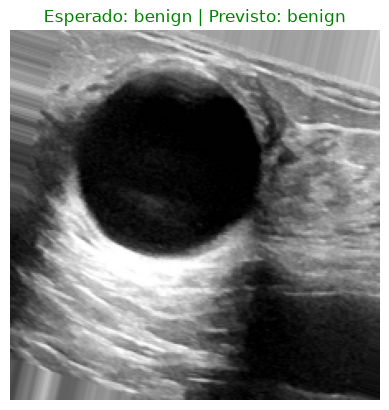

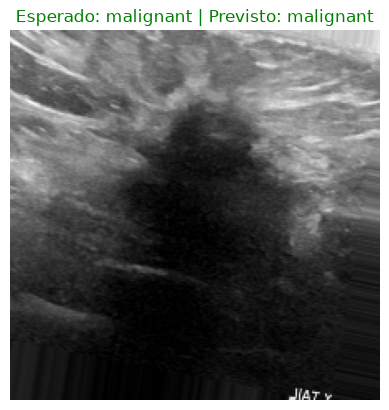

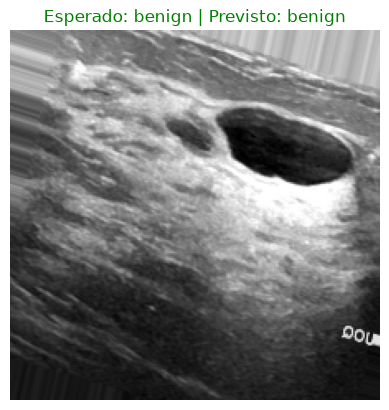

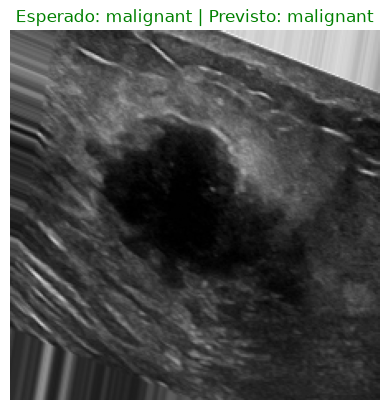

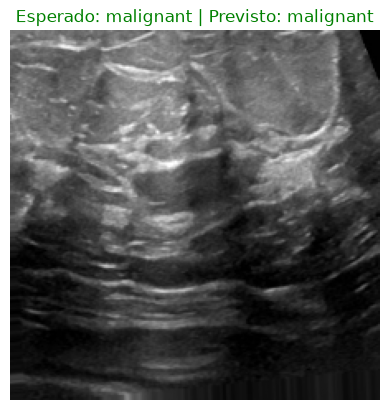

In [80]:
import matplotlib.pyplot as plt
import numpy as np

# Dicionário com as duas classes
class_names = {0: 'benign', 1: 'malignant'}

# Número de amostras que você quer prever
num_samples = 5

# Predição
predictions = model.predict(X_test[:num_samples])
predicted_classes = np.argmax(predictions, axis=1)

# Mostrar as imagens com a classe real e a prevista
for i in range(num_samples):
    plt.imshow(X_test[i].squeeze(), cmap='gray')  # .squeeze() remove canal extra se tiver
    esperado = class_names[y_test[i]]
    previsto = class_names[predicted_classes[i]]
    cor_titulo = 'green' if esperado == previsto else 'red'
    
    plt.title(f"Esperado: {esperado} | Previsto: {previsto}", color=cor_titulo)
    plt.axis('off')
    plt.show()


In [81]:
import os
import cv2
import numpy as np

# Caminhos das pastas
benign_path = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/BUSI_CLEAN/validation/benign'
malignant_path = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/BUSI_CLEAN/validation/malignant'

# Parâmetros
img_sz = 224
class_names = {0: 'benign', 1: 'malignant'}

def load_images_from_folder(folder_path, label):
    images = []
    labels = []

    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is not None:
            img = cv2.resize(img, (img_sz, img_sz))
            img = img.astype('float32') / 255.0
            img = np.expand_dims(img, axis=-1)  # (224, 224, 1)

            images.append(img)
            labels.append(label)

    return images, labels


In [82]:
benign_imgs, benign_labels = load_images_from_folder(benign_path, 0)
malignant_imgs, malignant_labels = load_images_from_folder(malignant_path, 1)

X_val = np.array(benign_imgs + malignant_imgs)
y_val = np.array(benign_labels + malignant_labels)

print(f'Total de imagens: {X_val.shape[0]}')
print(f'Benign: {np.sum(y_val == 0)} | Malignant: {np.sum(y_val == 1)}')


Total de imagens: 73
Benign: 47 | Malignant: 26


In [83]:
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Accuracy on test set: {accuracy*100:.2f}%")

Accuracy on test set: 80.82%


E0000 00:00:1786152780.580308   50042 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


In [84]:
from sklearn.metrics import confusion_matrix

# Predição
y_pred_probs = model.predict(X_val)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Matriz de confusão
conf_mat = confusion_matrix(y_val, y_pred_classes)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


E0000 00:00:1786152786.099396   50042 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [85]:
from sklearn.metrics import classification_report
import numpy as np

# 🔹 Predições no conjunto correto (900 imagens)
y_pred_probs = model.predict(X_val)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 🔹 Checagem de consistência (ESSENCIAL)
print(len(y_val), len(y_pred_classes))  # Deve ser: 900 900

# 🔹 Relatório de classificação
print(classification_report(
    y_val,
    y_pred_classes,
    target_names=['benign', 'malignant']
))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
73 73
              precision    recall  f1-score   support

      benign       0.87      0.83      0.85        47
   malignant       0.71      0.77      0.74        26

    accuracy                           0.81        73
   macro avg       0.79      0.80      0.79        73
weighted avg       0.81      0.81      0.81        73



3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
73 73


E0000 00:00:1786152791.801607   50042 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


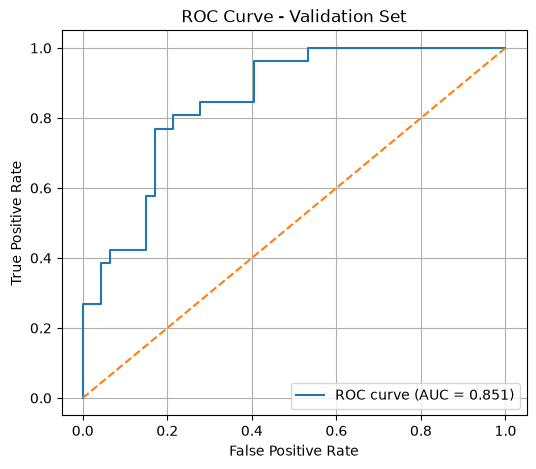

In [86]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 🔹 1. Recalcular predições com o conjunto correto (900 imagens)
y_pred_probs = model.predict(X_val)

# 🔹 2. Pegar probabilidade da classe positiva (malignant = 1)
y_scores = y_pred_probs[:, 1]

# 🔹 3. Conferência (boa prática)
print(len(y_val), len(y_scores))  # Deve ser: 900 900

# 🔹 4. Curva ROC
fpr, tpr, _ = roc_curve(y_val, y_scores)
roc_auc = auc(fpr, tpr)

# 🔹 5. Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Validation Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

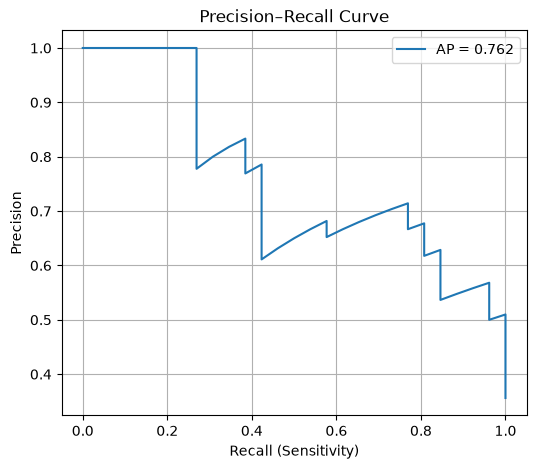

In [87]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_val, y_scores)
ap_score = average_precision_score(y_val, y_scores)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'AP = {ap_score:.3f}')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.legend()
plt.grid(True)
plt.show()


In [88]:
print(len(y_val), len(y_pred_classes))

73 73


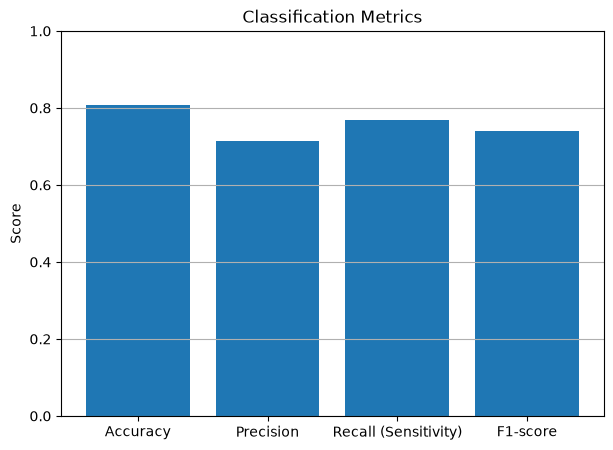

In [89]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_val, y_pred_classes)
precision = precision_score(y_val, y_pred_classes)
recall = recall_score(y_val, y_pred_classes)   # Sensibilidade (malignant)
f1 = f1_score(y_val, y_pred_classes)

metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall (Sensitivity)': recall,
    'F1-score': f1
}

plt.figure(figsize=(7, 5))
plt.bar(metrics.keys(), metrics.values())
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Classification Metrics')
plt.grid(axis='y')
plt.show()


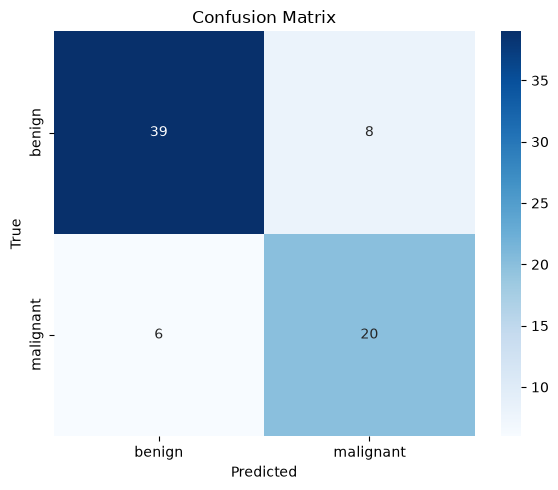

In [90]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['benign', 'malignant'],
    yticklabels=['benign', 'malignant']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


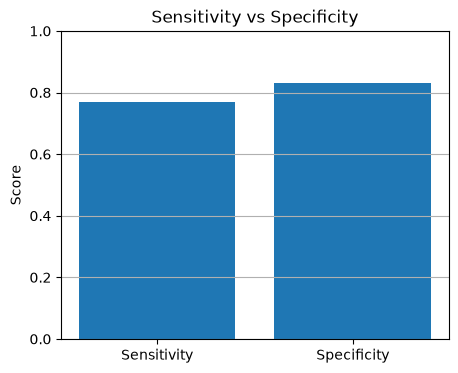

In [91]:
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

plt.figure(figsize=(5, 4))
plt.bar(['Sensitivity', 'Specificity'], [sensitivity, specificity])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Sensitivity vs Specificity')
plt.grid(axis='y')
plt.show()


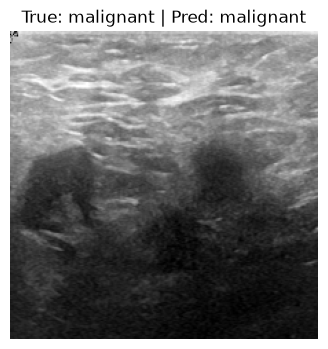

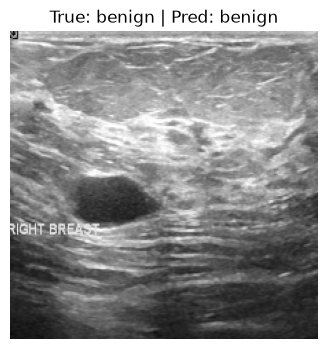

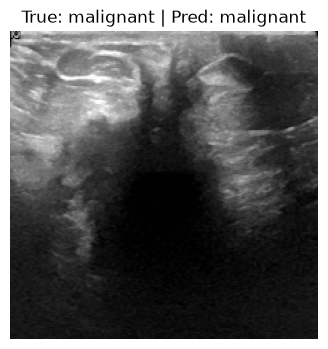

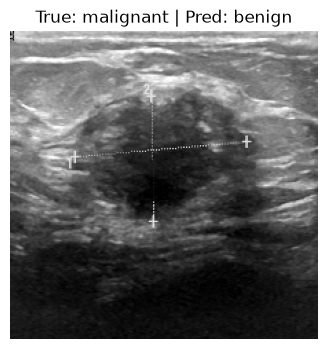

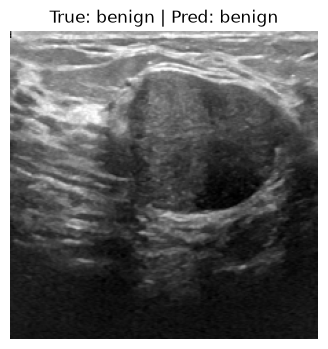

In [92]:
import numpy as np
import matplotlib.pyplot as plt

# Número de imagens para visualização
num_images = 5

# (Opcional) Para reprodutibilidade
np.random.seed(42)

for _ in range(num_images):
    # Índice aleatório
    random_idx = np.random.randint(0, len(X_val))

    # Imagem
    img = X_val[random_idx].squeeze()

    # Rótulos
    true_label = class_names[y_val[random_idx]]
    pred_label = class_names[y_pred_classes[random_idx]]

    # Plot
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_label} | Pred: {pred_label}")
    plt.axis('off')
    plt.show()



RESULTADO DA CLASSIFICAÇÃO
Arquivo: benign (188).png
Classe real: benign
Classe prevista: benign
Confiança: 0.9975
Probabilidades: [0.9975471  0.00245286]
Resultado: CORRETO


E0000 00:00:1786152800.253448   50042 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


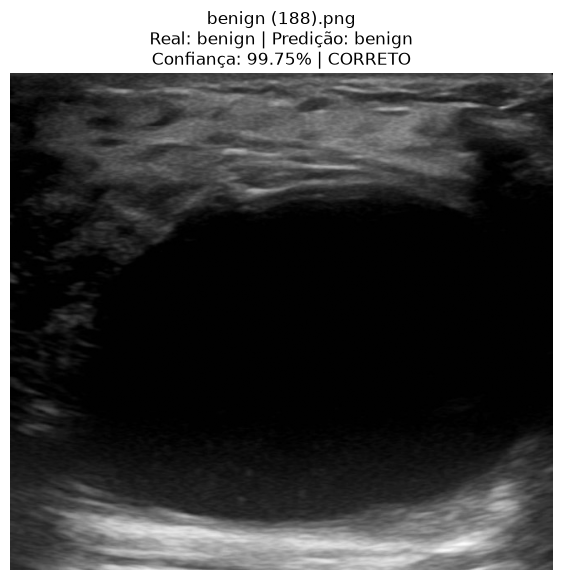

In [93]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# CAMINHO DO CONJUNTO DE TESTE
# ============================================================

test_dir = (
    '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/'
    'BUSI_CLEAN/test'
)


# ============================================================
# PARÂMETROS
# ============================================================

img_sz = 224

class_names = {
    0: 'benign',
    1: 'malignant'
}


# ============================================================
# SELECIONAR UMA IMAGEM ALEATÓRIA
# ENTRE AS DUAS CLASSES
# ============================================================

image_list = []

for class_name in ['benign', 'malignant']:

    class_dir = os.path.join(
        test_dir,
        class_name
    )

    for filename in os.listdir(class_dir):

        if filename.lower().endswith(
            ('.png', '.jpg', '.jpeg')
        ):

            image_list.append(
                (
                    os.path.join(
                        class_dir,
                        filename
                    ),
                    class_name,
                    filename
                )
            )


if len(image_list) == 0:
    raise ValueError(
        "Nenhuma imagem encontrada no conjunto de teste."
    )


# Seleciona uma imagem aleatória
img_path, real_class, filename = random.choice(
    image_list
)


# ============================================================
# FUNÇÃO DE PRÉ-PROCESSAMENTO
# ============================================================

def preprocess_image(img_path):

    # Carregar como grayscale
    img = cv2.imread(
        img_path,
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:
        raise ValueError(
            f"Erro ao carregar a imagem: {img_path}"
        )

    # Redimensionar
    img = cv2.resize(
        img,
        (img_sz, img_sz)
    )

    # Converter para float32
    img = img.astype('float32')

    # Normalizar para intervalo [0,1]
    img = img / 255.0

    # (224,224) -> (224,224,1)
    img = np.expand_dims(
        img,
        axis=-1
    )

    # (224,224,1) -> (1,224,224,1)
    img = np.expand_dims(
        img,
        axis=0
    )

    return img


# ============================================================
# PRÉ-PROCESSAR IMAGEM
# ============================================================

img_input = preprocess_image(
    img_path
)


# ============================================================
# FAZER PREDIÇÃO
# ============================================================

pred_probs = model.predict(
    img_input,
    verbose=0
)

pred_class = np.argmax(
    pred_probs,
    axis=1
)[0]

confidence = np.max(
    pred_probs
)

predicted_class = class_names[
    pred_class
]


# ============================================================
# VERIFICAR SE A PREDIÇÃO ESTÁ CORRETA
# ============================================================

correct = (
    predicted_class == real_class
)


# ============================================================
# MOSTRAR RESULTADO
# ============================================================

print("\n====================================")
print("RESULTADO DA CLASSIFICAÇÃO")
print("====================================")

print(f"Arquivo: {filename}")

print(f"Classe real: {real_class}")

print(
    f"Classe prevista: {predicted_class}"
)

print(
    f"Confiança: {confidence:.4f}"
)

print(
    f"Probabilidades: {pred_probs[0]}"
)


if correct:

    print("Resultado: CORRETO")

else:

    print("Resultado: INCORRETO")


# ============================================================
# EXIBIR IMAGEM
# ============================================================

img_display = cv2.imread(
    img_path,
    cv2.IMREAD_GRAYSCALE
)


plt.figure(
    figsize=(7, 7)
)

plt.imshow(
    img_display,
    cmap='gray'
)


status = (
    "CORRETO"
    if correct
    else "INCORRETO"
)


plt.title(
    f"{filename}\n"
    f"Real: {real_class} | "
    f"Predição: {predicted_class}\n"
    f"Confiança: {confidence:.2%} | "
    f"{status}"
)


plt.axis('off')

plt.show()

Colunas do CSV:
['ID', 'Pathology', 'kFold', 'valid_1', 'valid_2', 'valid_3', 'valid_4', 'valid_5']

Imagem selecionada:
bus_0535-l.png
ID procurado no CSV:
bus_0535-l
Classe real:
malignant

RESULTADO DA CLASSIFICAÇÃO
Arquivo: bus_0535-l.png
Classe real: malignant
Classe prevista: benign
Confiança: 0.9324
Probabilidades: [0.9323628  0.06763721]
Resultado: INCORRETO


E0000 00:00:1786152808.514730   50042 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


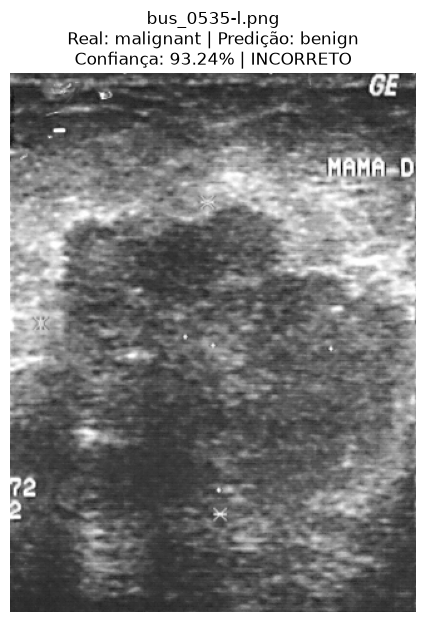

In [94]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# CAMINHOS
# ============================================================

images_dir = (
    '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/'
    'BUSBRA/Images'
)

csv_path = (
    '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/'
    'BUSBRA/5-fold-cv.csv'
)


# ============================================================
# CARREGAR O CSV
# ============================================================

df = pd.read_csv(csv_path)

# Remover possíveis espaços extras dos nomes das colunas
df.columns = df.columns.str.strip()

print("Colunas do CSV:")
print(df.columns.tolist())


# ============================================================
# SELECIONAR UMA IMAGEM ALEATÓRIA
# ============================================================

image_files = [
    file for file in os.listdir(images_dir)
    if file.lower().endswith(('.png', '.jpg', '.jpeg'))
]

if len(image_files) == 0:
    raise ValueError("Nenhuma imagem encontrada na pasta.")


selected_image = random.choice(image_files)

img_path = os.path.join(
    images_dir,
    selected_image
)


# ============================================================
# OBTER O ID DA IMAGEM
#
# Exemplo:
# bus_0930-r.png -> bus_0930-r
# ============================================================

image_id = os.path.splitext(selected_image)[0]


# ============================================================
# PROCURAR A CLASSE REAL NO CSV
# ============================================================

# Garantir que ID seja string e sem espaços extras
df['ID'] = df['ID'].astype(str).str.strip()

row = df[df['ID'] == image_id]


if row.empty:

    real_class = "não encontrada"

    print(
        f"\nAVISO: o ID {image_id} "
        "não foi encontrado no arquivo CSV."
    )

else:

    real_class = (
        row.iloc[0]['Pathology']
    )

    real_class = str(
        real_class
    ).strip().lower()


print("\nImagem selecionada:")
print(selected_image)

print("ID procurado no CSV:")
print(image_id)

print("Classe real:")
print(real_class)


# ============================================================
# PARÂMETROS DO MODELO
# ============================================================

img_sz = 224

class_names = {
    0: 'benign',
    1: 'malignant'
}


# ============================================================
# PRÉ-PROCESSAMENTO
# ============================================================

def preprocess_image(img_path):

    img = cv2.imread(
        img_path,
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:
        raise ValueError(
            f"Erro ao carregar a imagem: {img_path}"
        )

    # Redimensionar
    img = cv2.resize(
        img,
        (img_sz, img_sz)
    )

    # Converter para float
    img = img.astype('float32')

    # Normalização
    img = img / 255.0

    # (224,224) -> (224,224,1)
    img = np.expand_dims(
        img,
        axis=-1
    )

    # (224,224,1) -> (1,224,224,1)
    img = np.expand_dims(
        img,
        axis=0
    )

    return img


# ============================================================
# PRÉ-PROCESSAR
# ============================================================

img_input = preprocess_image(
    img_path
)


# ============================================================
# PREDIÇÃO
# ============================================================

pred_probs = model.predict(
    img_input,
    verbose=0
)

pred_class = np.argmax(
    pred_probs,
    axis=1
)[0]

confidence = np.max(
    pred_probs
)

predicted_class = class_names[
    pred_class
]


# ============================================================
# VERIFICAR SE ACERTOU
# ============================================================

if real_class != "não encontrada":

    correct = (
        predicted_class.lower()
        ==
        real_class.lower()
    )

else:

    correct = False


# ============================================================
# MOSTRAR RESULTADO
# ============================================================

print("\n====================================")
print("RESULTADO DA CLASSIFICAÇÃO")
print("====================================")

print(
    f"Arquivo: {selected_image}"
)

print(
    f"Classe real: {real_class}"
)

print(
    f"Classe prevista: {predicted_class}"
)

print(
    f"Confiança: {confidence:.4f}"
)

print(
    f"Probabilidades: {pred_probs[0]}"
)


if real_class != "não encontrada":

    if correct:

        print("Resultado: CORRETO")

    else:

        print("Resultado: INCORRETO")


# ============================================================
# EXIBIR IMAGEM
# ============================================================

img_display = cv2.imread(
    img_path,
    cv2.IMREAD_GRAYSCALE
)


plt.figure(
    figsize=(7, 7)
)

plt.imshow(
    img_display,
    cmap='gray'
)


if real_class != "não encontrada":

    status = (
        "CORRETO"
        if correct
        else "INCORRETO"
    )

    plt.title(
        f"{selected_image}\n"
        f"Real: {real_class} | "
        f"Predição: {predicted_class}\n"
        f"Confiança: {confidence:.2%} | "
        f"{status}"
    )

else:

    plt.title(
        f"{selected_image}\n"
        f"Predição: {predicted_class} "
        f"({confidence:.2%})\n"
        f"Classe real não encontrada"
    )


plt.axis('off')

plt.show()